In [9]:
import numpy as np
import bacco
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = {}

for i in range(len(name_list)):
    if i<30:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_{:d}/hydro_output/".format(i)
    else:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), use_ids=True, numpart=4320)


2026-02-20 16:33:33,752 bacco.sims : Initialising simulation Default
2026-02-20 16:33:33,753 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264
2026-02-20 16:33:33,828 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264
2026-02-20 16:33:34,342 bacco.sims : ...done in 0.0944 s
2026-02-20 16:33:34,343 bacco.sims : Initialising simulation Default
2026-02-20 16:33:34,344 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-02-20 16:33:34,412 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-02-20 16:33:34,925 bacco.sims : ...done in 0.0893 s
2026-02-20 16:33:34,926 bacco.sims : Initialising simulation Default
2026-02-20 16:33:34,928 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264
2

In [5]:
# Load the Halo Selection
with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

# Perform the cross-match with MTNG halos
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264, name=name_list[i])

# Load MTNG and get the fraction of halos to do the upweighting
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

h_frac = np.zeros(len(final_sel))
for m in range(len(mbins)-1):
    h_frac[m] = np.where(( m200b[final_sel]>=mbins[m]) & ( m200b[final_sel]<mbins[m+1]))[0].shape[0] / \
             np.where(( m200b>=mbins[m]) & ( m200b<mbins[m+1]))[0].shape[0]

zoom_split = {}
zoom_sel = {}
for i in range(len(name_list)):
    zoom_split[name_list[i]] = utils.split_halos(zoom[name_list[i]])

    zoom_sel[name_list[i]] = {}

    zoom_sel[name_list[i]]['sel'] = xmatch[name_list[i]]['ind'][:,np.newaxis,np.newaxis]
    zoom_sel[name_list[i]]['h_frac'] = h_frac[np.newaxis, :]

2026-02-20 16:33:44,177 bacco.sims : Initialising simulation Default
2026-02-20 16:33:44,177 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-02-20 16:33:44,178 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-02-20 16:33:44,208 bacco.sims : ...done in 0.0054 s
2026-02-20 16:33:44,211 bacco.sims : Reading 98233510 items for Group_M_Mean200


/tmp/ipykernel_219770/87356854.py:19: RuntimeWarning: divide by zero encountered in log10
  m200b = np.log10(1e10 * mtng.fof['halo_m200b'])


In [29]:
bh_mf = {}

for i in range(len(name_list)):
    bh_mf[name_list[i]] = zoom_split[name_list[i]].bh_mf(sel_mask=zoom_sel[name_list[i]], nbins=20)

2026-02-20 16:54:17,213 bacco.sims : Reading 142791 items for halo_firstsub
2026-02-20 16:54:17,702 bacco.sims : Reading 142791 items for GroupNsubs
2026-02-20 16:54:17,716 bacco.sims : Reading 76572 items for SubhaloBHMass
2026-02-20 16:54:18,222 bacco.sims : Reading 143520 items for halo_firstsub
2026-02-20 16:54:18,782 bacco.sims : Reading 143520 items for GroupNsubs
2026-02-20 16:54:18,795 bacco.sims : Reading 74995 items for SubhaloBHMass
2026-02-20 16:54:19,195 bacco.sims : Reading 146601 items for halo_firstsub
2026-02-20 16:54:19,656 bacco.sims : Reading 146601 items for GroupNsubs
2026-02-20 16:54:19,670 bacco.sims : Reading 76208 items for SubhaloBHMass
2026-02-20 16:54:20,138 bacco.sims : Reading 141432 items for halo_firstsub
2026-02-20 16:54:20,728 bacco.sims : Reading 141432 items for GroupNsubs
2026-02-20 16:54:20,741 bacco.sims : Reading 75118 items for SubhaloBHMass
2026-02-20 16:54:21,274 bacco.sims : Reading 145271 items for halo_firstsub
2026-02-20 16:54:21,933 bacc

In [27]:
mtng_bhmf = utils.get_mtng_bhmf(mtng, nbins=20)

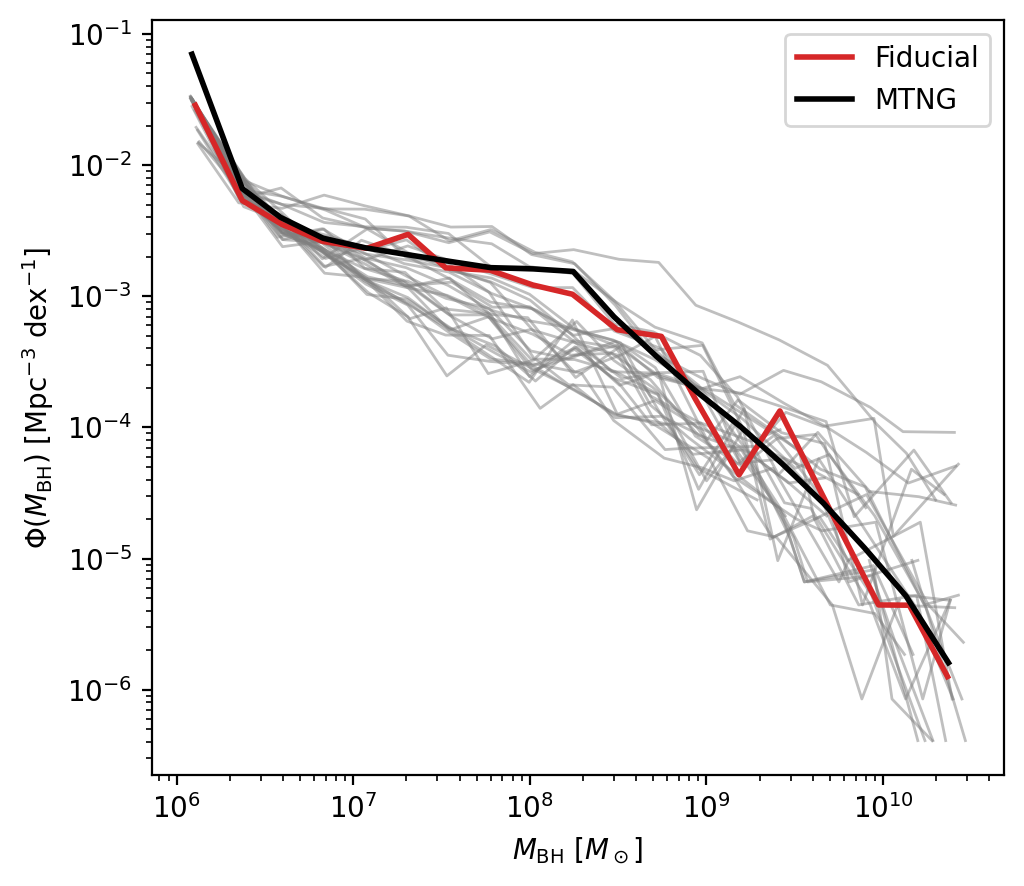

In [36]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r"$\Phi(M_{\rm BH})$ [Mpc$^{-3}$ dex$^{-1}$]")
ax.set_xlabel(r"$M_{\rm BH}$ [$M_\odot$]")

for i in range(len(name_list)-1):
    ax.plot(bh_mf[name_list[i]]['mbh'], bh_mf[name_list[i]]['bhmf'], color='gray', alpha=0.5, lw=1)

ax.plot(bh_mf['fiducial']['mbh'], bh_mf['fiducial']['bhmf'], label='Fiducial', color='C3', lw=2)
ax.plot(mtng_bhmf['mbh'], mtng_bhmf['bhmf'], label='MTNG', color='k', lw=2)

ax.legend()
